Step 1 Importing necessary libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

#Step 2 Loading the dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

#Step 3 Summarizing the dataset

In [ ]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [ ]:
y_train[0]

np.uint8(9)

In [ ]:
x_test[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  13,  67,   0,
          0,   0,   0,  50,  38,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   8, 120, 209, 226, 247, 237,
        255, 255, 255, 247, 238, 235, 172,  72,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 137, 239, 252, 243, 234, 229, 238,
        244, 246, 240, 230, 232, 239, 248, 251, 194,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 102, 255, 231, 228, 227, 228, 233, 230,
        230, 229, 228, 232, 232, 231, 227, 224, 252, 179,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 233, 241, 229, 231, 255, 255, 238, 231,
        227, 238, 246, 228, 230, 227, 234, 235, 229, 241,  20,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 248, 241, 231, 255, 149,  47, 252, 228,
        255, 242, 216, 238, 232, 255, 228, 220, 234, 250,  54,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 255, 240, 232, 255,  15,   0, 255, 237,
        191,   0,   0, 214, 255,  13, 123, 255, 234, 252, 114,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   6, 255, 238, 239, 255, 177,   0, 255, 255,
          0, 130, 116,  47,  65,  43,  37, 255, 236, 249, 162,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  32, 255, 236, 245, 255, 204,   0, 255,  84,
          0,  37,  28,  31,   0,  25,  13, 255, 236, 249, 199,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  53, 255, 236, 250, 250, 231,   2, 255,  21,
          0, 221, 255, 236,  54, 245, 198, 243, 238, 245, 223,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  80, 255, 237, 250, 240, 255,   0,   0,  39,
        157,   0,   0, 215,  94,  20, 126, 255, 237, 239, 250,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 101, 255, 235, 253, 244, 243, 133, 138, 208,
        255, 201, 214, 255, 230,   7, 174, 255, 240, 238, 255,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 126, 255, 233, 255, 248, 233, 255, 255, 240,
        232, 243, 243, 231, 251, 255, 255, 254, 243, 238, 255,   3,   0,
          0,   0],
       [  0,   0,   0,   0, 147, 255, 233, 249, 181, 243, 227, 224, 230,
        234, 230, 230, 235, 228, 235, 222, 207, 255, 236, 255,  35,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 255, 245, 221,  86, 255, 233, 233, 235,
        236, 234, 234, 234, 232, 242, 231, 125, 255, 236, 255,  55,   0,
          0,   0],
       [  0,   0,   0,   0, 181, 254, 255, 200,  69, 255, 228, 232, 234,
        235, 234, 234, 233, 235, 241, 237,  70, 255, 235, 246,  57,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 247, 255, 188, 110, 255, 224, 233, 234,
        234, 234, 234, 234, 234, 240, 253,  69, 255, 236, 248,  77,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 246, 255, 149, 145, 255, 223, 235, 234,
        235, 235, 235, 234, 237, 233, 255,  47, 255, 239, 249,  98,   0,
          0,   0],
       [  0,   0,   0,   0, 204, 243, 255, 111, 173, 255, 227, 235, 235,
        236, 235, 235, 235, 239, 229, 255,  19, 227, 246, 249, 110,   0,
          0,   0],
       [  0,   0,   0,   0, 196, 240, 255, 109, 213, 250, 229, 235, 235,
        236, 235, 237, 236, 237, 226, 255,  55, 203, 251, 245, 120,   0,
          0,   0],
       [  0,   0,   0,   0, 192, 243, 255, 114, 232, 240, 232, 235, 235,
        236, 234, 237, 236, 235, 229, 255, 134, 171, 252, 244, 137,   0,
          0,   0],
       [  0,   0,   0,   0, 189, 251, 255, 154, 238, 233, 236, 234, 235,
        236, 235, 238, 236, 235, 232, 255, 166, 125, 255, 243, 142,   0,
          0,   0],
       [  0,   0,   0,   0, 183, 252, 255, 171, 247, 232, 234, 234, 233,
        233, 232, 234, 233, 234, 233, 240, 223, 128, 255, 242, 151,   0,
          0,   0],
       [  0,   0,   0,   0, 178, 243, 255,  57, 238, 241, 238, 238, 238,
        237, 236, 237, 237, 240, 237, 254, 176,  52, 255, 239, 157,   0,
          0,   0],
       [  0,   0,   0,   0, 188, 240, 25

In [ ]:
y_test[1]

np.uint8(2)

In [ ]:
x_train[59999]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   1,  71,  13,   4,   0,   0,   1,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,  62,  13,   0,  34,   0,   0,   0,   0,   0,   4,  42,  19,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0, 104,  68,   0,  51,  37,  28,  19,  47,  72,  95, 109,  59,
          0,   0],
       [  0,   0,   1,   0,   0,   1,   1,   0,   0,   1,   1,   0,   0,
          0,   0, 148, 133,  28,  42,  33,  27,  94,  98,  54,  97,  57,
          0,   3],
       [  1,   0,   1,   0,   4,   0,   0,   0,   0,   0,   0,   1,   0,
          6,   0,  27, 119, 101,   4,  75,  37,  27,  81, 130,  94,   0,
          0,   1],
       [  3,   1,   0,   0,   0,   0, 133, 157,   7,  21,   1,   0,   0,
          0,   0,   0,   0, 106, 145,  86,   4,  80, 124,  25,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   9,  56, 144, 133, 129, 153,  34,   0,   3,
          3,   0,   3,   0,  24, 104,  89, 104, 109,   0,   0,   0,   1,
          1,   0],
       [  1,   1,   3,   0,  25, 157, 170, 157, 201, 204,  25,   0,   0,
          0,   0,   0,   0,  51,  86,  94,  92,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  37,  91,   0,   0,  86,   0,   0,   0,
         36,  92, 129, 148,  66, 100,  68,  98, 173, 133, 122, 136, 127,
        112,  21],
       [ 22,  27,  19,  37,  44,  83,  59,  56,  45,  51, 163, 177, 173,
        200, 176, 177, 188,  66, 122,  89,  92, 183, 174, 185, 180, 177,
        177,  47],
       [101, 235, 194, 223, 232, 255,  98,  75,  54, 136,  85, 218, 186,
        186, 168, 195, 177,  37,  48,  22,  77, 221, 191, 183, 180, 160,
        186,  57],
       [  4,  86,  62,  54,  34,  28,  95,  86,  81,  98,  78,  77,  83,
         75,  88,  88,  89,  63,  75,  81,  86,  88,  66,  51,  42,  21,
         18,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
y_train[59999]

np.uint8(5)

In [ ]:
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

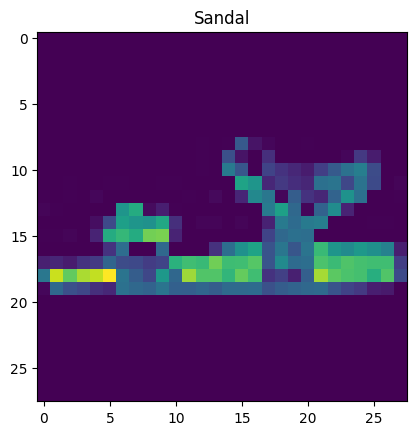

In [ ]:
#display one image
plt.imshow(x_train[59999])
plt.title(class_labels[y_train[59999]])
plt.show()

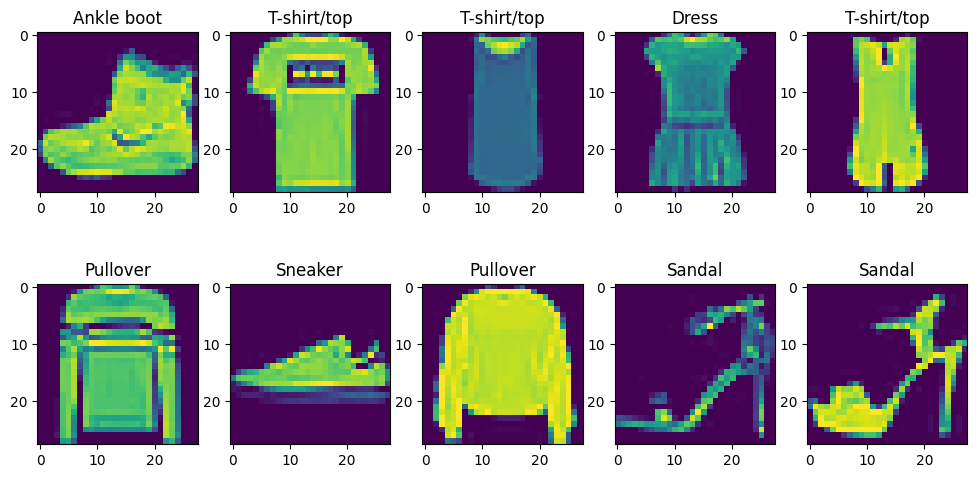

In [ ]:
plt.figure(figsize=(12,6))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(class_labels[y_train[i]])

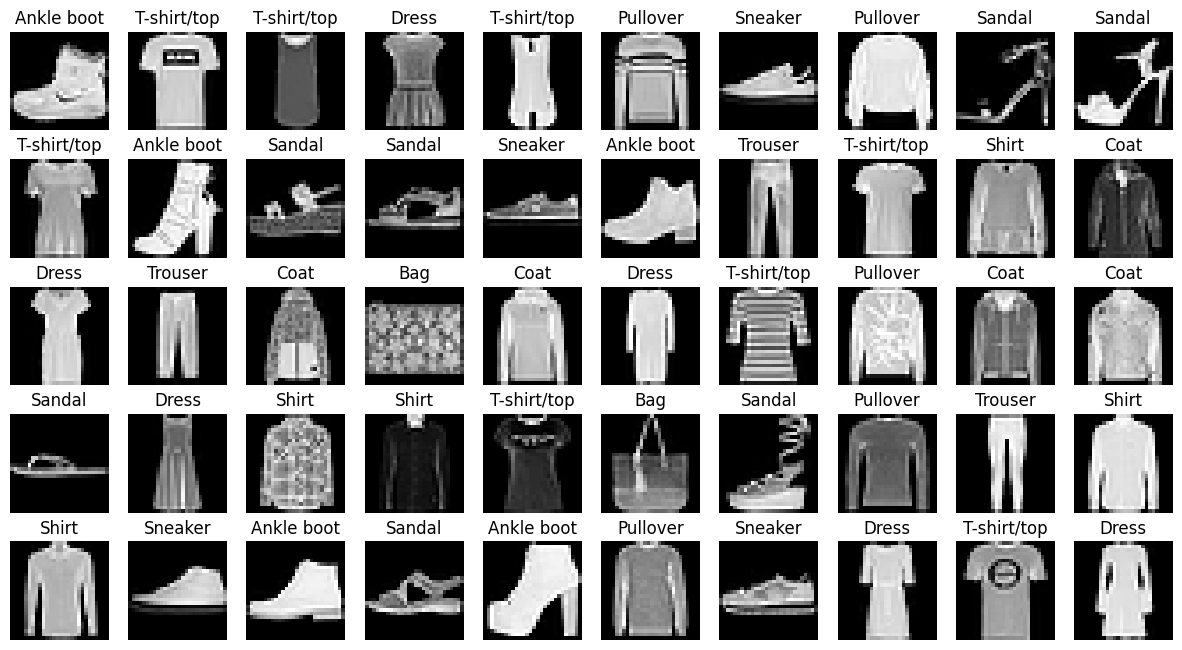

In [ ]:
plt.figure(figsize=(15,8))
for i in range(50):
  plt.subplot(5,10,i+1)
  plt.imshow(x_train[i], cmap='grey')
  plt.title(class_labels[y_train[i]])
  plt.axis('off')

#Step 4 : preprocessing the dataset

Preprocessing step 1 convert to float

In [ ]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [ ]:
x_train_f = x_train.astype('float32')
x_test_f = x_test.astype('float32')

In [ ]:
x_train_f[0]

array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,  13.,  73.,   0.,   0.,   1.,   4.,   0.,
          0.,   0.,   0.,   1.,   1.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   3.,   0.,  36., 136., 127.,  62.,  54.,   0.,   0.,   0.,
          1.,   3.,   4.,   0.,   0.,   3.],
       [  0.,   0.,   0.,   0.,   0

In [ ]:
x_test_f[0]

array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0

Preprocessing step 2 Add channel dimension

In [ ]:
x_train_f.shape

(60000, 28, 28)

In [ ]:
x_train_d = np.expand_dims(x_train_f, axis=-1)
x_test_d = np.expand_dims(x_test_f, axis=-1)

In [ ]:
x_train_d

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [ ]:
x_test_d

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

preprocessing step 3 resizing images from 28x28 to 32x32

In [ ]:
x_train_r = tf.image.resize(x_train_d,[32,32])

In [ ]:
x_train_r

<tf.Tensor: shape=(60000, 32, 32, 1), dtype=float32, numpy=
array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
  

In [ ]:
x_test_r = tf.image.resize(x_test_d,[32,32])

In [ ]:
x_test_r

<tf.Tensor: shape=(10000, 32, 32, 1), dtype=float32, numpy=
array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
  

preprocessing step 4 : convert grey scale to RGB  (from 32x32x1(1D) to 32x32x3(3D))

In [ ]:
x_train_rgb = tf.image.grayscale_to_rgb(x_train_r)

In [ ]:
x_train_rgb

<tf.Tensor: shape=(60000, 32, 32, 3), dtype=float32, numpy=
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],




In [ ]:
x_test_rgb = tf.image.grayscale_to_rgb(x_test_r)

In [ ]:
x_test_rgb

<tf.Tensor: shape=(10000, 32, 32, 3), dtype=float32, numpy=
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]],




preprcessing step 5 : convert tensorflow tensor to numpy

In [ ]:
#convert tensorflow tensor to numpy
x_train_arr = x_train_rgb.numpy()
x_test_arr = x_test_rgb.numpy()

preprocessing step 6 : VGG-16 preprocessing

In [ ]:
#applying VGG-16 preprocessing
x_train_arr_vgg16 = preprocess_input(x_train_arr)

In [ ]:
x_test_arr_vgg16 = preprocess_input(x_test_arr)

preprocessing step 7 : preprocessing the output

In [ ]:
print(y_train)

[9 0 0 ... 3 0 5]


In [ ]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [ ]:
y_train_hot = keras.utils.to_categorical(y_train)

In [ ]:
y_test_hot = keras.utils.to_categorical(y_test)

#Step 5 : Segregatting the Dataset into input and output

Input = images(x)

output = Class Labels(y)

#Step 6 : Splitting the dataset into training testing and validation



1.   training data = 60000

2.   Testing data = 10000

3.   Validation data = 20% of training data



In [ ]:
#splitting the training data into training and validation data
X_Train,X_Val,Y_Train,Y_Val = train_test_split(x_train_arr_vgg16,y_train_hot,test_size=0.2,random_state = 42)

In [ ]:
X_Train.shape

(48000, 32, 32, 3)

In [ ]:
X_Val.shape

(12000, 32, 32, 3)

In [ ]:
Y_Train.shape

(48000, 10)

In [ ]:
Y_Val.shape

(12000, 10)

In [ ]:
print("training data",X_Train.shape,Y_Train.shape)
print("Validation data",X_Val.shape,Y_Val.shape)
print("Testing data",x_test_arr_vgg16.shape,y_test_hot.shape)

training data (48000, 32, 32, 3) (48000, 10)
Validation data (12000, 32, 32, 3) (12000, 10)
Testing data (10000, 32, 32, 3) (10000, 10)


#Step 7 : Loading the pre-trained VGG-16 Model

In [ ]:
base_model=VGG16(weights="imagenet",include_top=False,input_shape=(32,32,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#Step 8 : Freezing the pre-trained layers

1.feature extraction

In [ ]:
base_model.trainable

True

In [ ]:
base_model=VGG16(weights="imagenet",include_top=False,input_shape=(32,32,3))
base_model.trainable = False

In [ ]:
base_model.trainable

False

In [ ]:
inputs = tf.keras.Input(shape=(32, 32, 3))

In [ ]:
inputs

<KerasTensor shape=(None, 32, 32, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_38>

In [ ]:
# Pass inputs through the pre-trained VGG16 features
x = base_model(inputs, training=False)

In [ ]:
x

<KerasTensor shape=(None, 1, 1, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_39>

In [ ]:
# Convert features into a 1D vector and add your Dense layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

In [ ]:
x

<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_41>

In [ ]:
# Final output layer (change 'num_classes' to match your dataset)
num_classes = 10
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [ ]:
model

<Functional name=functional, built=True>

In [ ]:
# Step 3: Compile the model
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])               # Use 'sparse_categorical_crossentropy' if targets are integers


In [ ]:
# Step 4: Train the model
model.fit(X_Train, Y_Train, epochs=10, validation_data=(X_Val, Y_Val))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7799 - loss: 0.9726 - val_accuracy: 0.8303 - val_loss: 0.4879
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8419 - loss: 0.4374 - val_accuracy: 0.8302 - val_loss: 0.4705
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8585 - loss: 0.3880 - val_accuracy: 0.8424 - val_loss: 0.4431
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8662 - loss: 0.3623 - val_accuracy: 0.8493 - val_loss: 0.4353
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8733 - loss: 0.3433 - val_accuracy: 0.8488 - val_loss: 0.4499
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8796 - loss: 0.3229 - val_accuracy: 0.8540 - val_loss: 0.4450
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8852 - loss: 0.3055 - val_accuracy: 0.8482 - val_loss: 0.4600
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8910 - loss:

#Give a new fabric image to your trained model

In [ ]:
import numpy as np
from PIL import Image
from google.colab import files
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
# Upload a new fabric image from your computer
uploaded = files.upload()

Saving denim_004.jpg to denim_004.jpg
Saving denim_007.jpg to denim_007.jpg
Saving denim_011.jpg to denim_011.jpg
Saving denim_013.jpg to denim_013.jpg
Saving denim_016.jpg to denim_016.jpg
Saving denim_001.jpg to denim_001.jpg
Saving denim_002.jpg to denim_002.jpg
Saving denim_003.jpg to denim_003.jpg
Saving denim_005.jpg to denim_005.jpg
Saving denim_006.jpg to denim_006.jpg
Saving denim_008.jpg to denim_008.jpg
Saving denim_009.jpg to denim_009.jpg
Saving denim_010.jpg to denim_010.jpg
Saving denim_012.jpg to denim_012.jpg
Saving denim_014.jpg to denim_014.jpg
Saving denim_015.jpg to denim_015.jpg


In [ ]:
# Upload a new fabric image from your computer
uploaded = files.upload()

Saving silk_001.jpg to silk_001.jpg
Saving silk_002.jpg to silk_002.jpg
Saving silk_003.jpg to silk_003.jpg
Saving silk_004.jpg to silk_004.jpg
Saving silk_005.jpg to silk_005.jpg
Saving silk_006.jpg to silk_006.jpg
Saving silk_007.jpg to silk_007.jpg
Saving silk_008.jpg to silk_008.jpg
Saving silk_009.jpg to silk_009.jpg
Saving silk_010.jpg to silk_010.jpg
Saving silk_011.jpg to silk_011.jpg
Saving silk_012.jpg to silk_012.jpg
Saving silk_013.jpg to silk_013.jpg
Saving silk_014.jpg to silk_014.jpg
Saving silk_015.jpg to silk_015.jpg
Saving silk_016.jpg to silk_016.jpg


In [ ]:
# Upload a new fabric image from your computer
uploaded = files.upload()

Saving cotton_001.jpg to cotton_001.jpg
Saving cotton_002.jpg to cotton_002.jpg
Saving cotton_003.jpg to cotton_003.jpg
Saving cotton_004.jpg to cotton_004.jpg
Saving cotton_005.jpg to cotton_005.jpg
Saving cotton_006.jpg to cotton_006.jpg
Saving cotton_007.jpg to cotton_007.jpg
Saving cotton_008.jpg to cotton_008.jpg
Saving cotton_009.jpg to cotton_009.jpg
Saving cotton_010.jpg to cotton_010.jpg
Saving cotton_011.jpg to cotton_011.jpg
Saving cotton_012.jpg to cotton_012.jpg
Saving cotton_013.jpg to cotton_013.jpg
Saving cotton_014.jpg to cotton_014.jpg
Saving cotton_015.jpg to cotton_015.jpg
Saving cotton_016.jpg to cotton_016.jpg


In [ ]:
# Upload a new fabric image from your computer
uploaded = files.upload()

Saving polyester_001.jpg to polyester_001.jpg
Saving polyester_002.jpg to polyester_002.jpg
Saving polyester_003.jpg to polyester_003.jpg
Saving polyester_004.jpg to polyester_004.jpg
Saving polyester_005.jpg to polyester_005.jpg
Saving polyester_006.jpg to polyester_006.jpg
Saving polyester_007.jpg to polyester_007.jpg
Saving polyester_008.jpg to polyester_008.jpg
Saving polyester_009.jpg to polyester_009.jpg
Saving polyester_010.jpg to polyester_010.jpg
Saving polyester_011.jpg to polyester_011.jpg
Saving polyester_012.jpg to polyester_012.jpg
Saving polyester_013.jpg to polyester_013.jpg
Saving polyester_014.jpg to polyester_014.jpg
Saving polyester_015.jpg to polyester_015.jpg
Saving polyester_016.jpg to polyester_016.jpg


In [ ]:
# Upload a new fabric image from your computer
uploaded = files.upload()

Saving wool_001.jpg to wool_001.jpg
Saving wool_002.jpg to wool_002.jpg
Saving wool_003.jpg to wool_003.jpg
Saving wool_004.jpg to wool_004.jpg
Saving wool_005.jpg to wool_005.jpg
Saving wool_006.jpg to wool_006.jpg
Saving wool_007.jpg to wool_007.jpg
Saving wool_008.jpg to wool_008.jpg
Saving wool_009.jpg to wool_009.jpg
Saving wool_010.jpg to wool_010.jpg
Saving wool_011.jpg to wool_011.jpg
Saving wool_012.jpg to wool_012.jpg
Saving wool_013.jpg to wool_013.jpg
Saving wool_014.jpg to wool_014.jpg
Saving wool_015.jpg to wool_015.jpg
Saving wool_016.jpg to wool_016.jpg


#Check the uploaded files and build labels from file names

In [ ]:
import os, glob
import numpy as np
from PIL import Image

IMG_SIZE = 224   # bigger than 32 so fabric texture stays visible

image_files = sorted(f for f in os.listdir('/content')
                     if f.lower().endswith(('.jpg', '.jpeg', '.png')) and '_' in f)

labels_text = [f.rsplit('_', 1)[0].lower() for f in image_files]
fabric_labels = sorted(set(labels_text))          # NEW class list (replaces class_labels)
num_fabric_classes = len(fabric_labels)

print("Total images:", len(image_files))
print("Fabric classes:", fabric_labels)
for c in fabric_labels:
    print(f"  {c}: {labels_text.count(c)} images")

Total images: 80
Fabric classes: ['cotton', 'denim', 'polyester', 'silk', 'wool']
  cotton: 16 images
  denim: 16 images
  polyester: 16 images
  silk: 16 images
  wool: 16 images


You should see 80 images and 5 classes.

#Load the images into arrays

In [ ]:
X_fab = []
y_fab = []
for f, lbl in zip(image_files, labels_text):
    img = Image.open(os.path.join('/content', f)).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    X_fab.append(np.array(img, dtype=np.float32))
    y_fab.append(fabric_labels.index(lbl))   # text label -> number

X_fab = np.array(X_fab)
y_fab = np.array(y_fab)
print(X_fab.shape, y_fab.shape)   # expected: (80, 224, 224, 3) (80,)

(80, 224, 224, 3) (80,)


#Look at a few images to confirm the labels are right

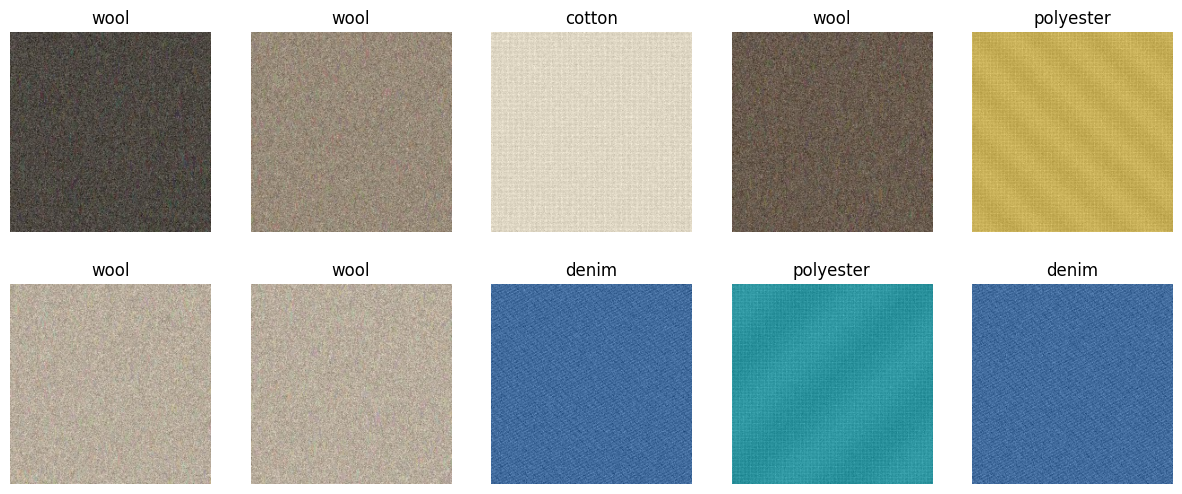

In [ ]:
plt.figure(figsize=(15, 6))
for i, idx in enumerate(np.random.choice(len(X_fab), 10, replace=False)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_fab[idx].astype('uint8'))
    plt.title(fabric_labels[y_fab[idx]])
    plt.axis('off')
plt.show()

#Preprocess the inputs and outputs

This mirrors your Fashion-MNIST steps: VGG16 preprocessing on the images, one-hot encoding on the labels.

In [ ]:
X_fab_vgg = preprocess_input(X_fab.copy())
y_fab_hot = keras.utils.to_categorical(y_fab, num_fabric_classes)
print(X_fab_vgg.shape, y_fab_hot.shape)   # (80, 224, 224, 3) (80, 5)

(80, 224, 224, 3) (80, 5)


#Split into training, validation and testing.

stratify keeps every fabric present in each split, which matters with only 16 images per class.

In [ ]:
X_tr, X_tmp, Y_tr, Y_tmp = train_test_split(
    X_fab_vgg, y_fab_hot, test_size=0.30, stratify=y_fab, random_state=42)
X_va, X_te, Y_va, Y_te = train_test_split(
    X_tmp, Y_tmp, test_size=0.50, stratify=Y_tmp.argmax(axis=1), random_state=42)

print("Train:", X_tr.shape, " Val:", X_va.shape, " Test:", X_te.shape)

Train: (56, 224, 224, 3)  Val: (12, 224, 224, 3)  Test: (12, 224, 224, 3)


In [ ]:
X_tr, X_tmp, Y_tr, Y_tmp = train_test_split(
    X_fab_vgg, y_fab_hot, test_size=0.30, stratify=y_fab, random_state=42)
X_va, X_te, Y_va, Y_te = train_test_split(
    X_tmp, Y_tmp, test_size=0.50, stratify=Y_tmp.argmax(axis=1), random_state=42)

print("Train:", X_tr.shape, " Val:", X_va.shape, " Test:", X_te.shape)

Train: (56, 224, 224, 3)  Val: (12, 224, 224, 3)  Test: (12, 224, 224, 3)


#Build a NEW model for fabrics (frozen VGG16)

This is a fresh VGG16 at 224×224 with an output layer of 5 neurons, not 10. The augmentation layers create flipped, rotated and zoomed variations during training only, which helps a lot with small datasets.

In [ ]:
fabric_base = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
fabric_base.trainable = False      # freeze VGG16

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
], name="augmentation")

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augmentation(inputs)
x = fabric_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_fabric_classes, activation='softmax')(x)

fabric_model = models.Model(inputs, outputs, name="fabric_model")
fabric_model.summary()

Model: "fabric_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#Train only the new layers (feature extraction)

In [ ]:
fabric_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                           restore_best_weights=True)

history1 = fabric_model.fit(X_tr, Y_tr, epochs=30, batch_size=16,
                            validation_data=(X_va, Y_va), callbacks=[early_stop])

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 635ms/step - accuracy: 0.2321 - loss: 2.6375 - val_accuracy: 0.4167 - val_loss: 1.3218
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.4107 - loss: 1.7625 - val_accuracy: 0.7500 - val_loss: 0.6201
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.4464 - loss: 1.8397 - val_accuracy: 0.9167 - val_loss: 0.2977
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5714 - loss: 0.9956 - val_accuracy: 0.8333 - val_loss: 0.4158
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6429 - loss: 1.0070 - val_accuracy: 0.8333 - val_loss: 0.4976
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7500 - loss: 0.6038 - val_accuracy: 0.8333 - val_loss: 0.3829
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.8214 - loss: 0.6145 - val_accuracy: 0.9167 - val_loss: 0.2511
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8571 - loss: 0.4093 - val_accuracy: 0.9167 - val_loss:

#Fine-tune: unfreeze only the last VGG16 block

Use a very small learning rate so the pre-trained weights aren't destroyed. You must compile again after changing trainable, otherwise nothing changes.

In [ ]:
fabric_base.trainable = True
for layer in fabric_base.layers:
    layer.trainable = layer.name.startswith('block5')

print("Unfrozen:", [l.name for l in fabric_base.layers if l.trainable])

fabric_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])

history2 = fabric_model.fit(X_tr, Y_tr, epochs=20, batch_size=16,
                            validation_data=(X_va, Y_va), callbacks=[early_stop])

Unfrozen: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 1.0000 - loss: 0.0473 - val_accuracy: 1.0000 - val_loss: 0.0367
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 1.0000 - loss: 0.0198 - val_accuracy: 1.0000 - val_loss: 0.0185
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9643 - loss: 0.0985 - val_accuracy: 1.0000 - val_loss: 0.0284
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.9643 - loss: 0.1031 - val_accuracy: 1.0000 - val_loss: 0.0391
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.9643 - loss: 0.1051 - val_accuracy: 1.0000 - val_loss: 0.0382
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.9821 - loss: 0.1078 - val_accuracy: 1.0000 - val_loss: 0.0262
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.9643 - loss: 0.0930 - val_accuracy: 1.0000 - val_loss: 0.0165
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms

#Plot training and check test accuracy

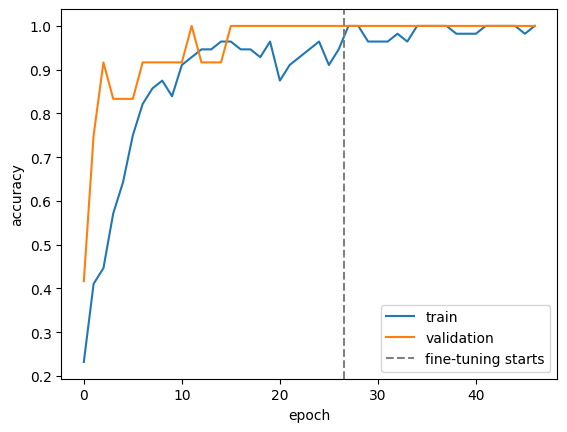

Test accuracy: 100.00%


In [ ]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
plt.plot(acc, label='train'); plt.plot(val_acc, label='validation')
plt.axvline(len(history1.history['accuracy']) - 0.5, ls='--', c='gray', label='fine-tuning starts')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.show()

test_loss, test_acc = fabric_model.evaluate(X_te, Y_te, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%")

#Predict a new fabric image

Note the two key changes from your old code: it uses fabric_model (not model) and fabric_labels (not class_labels), and it resizes to 224.

Saving fabric_dataset_starter (1).zip to fabric_dataset_starter (1) (1).zip
Extracting and predicting on images inside ZIP file: fabric_dataset_starter (1) (1).zip


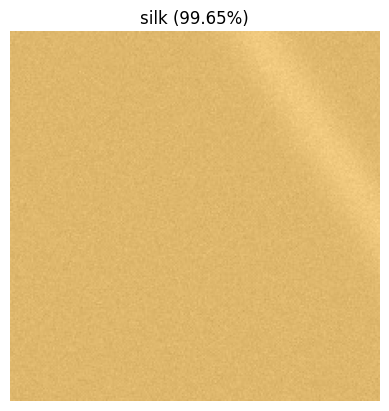

silk_012.jpg -> Predicted Fabric: silk (99.65%)


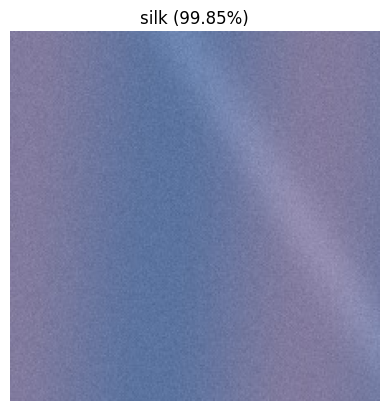

silk_010.jpg -> Predicted Fabric: silk (99.85%)


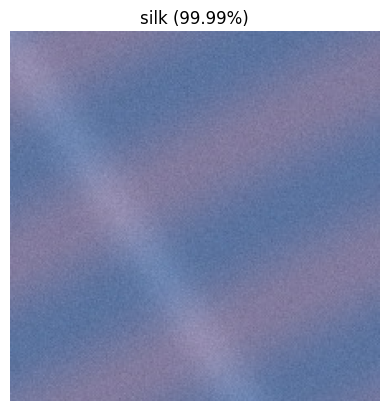

silk_011.jpg -> Predicted Fabric: silk (99.99%)


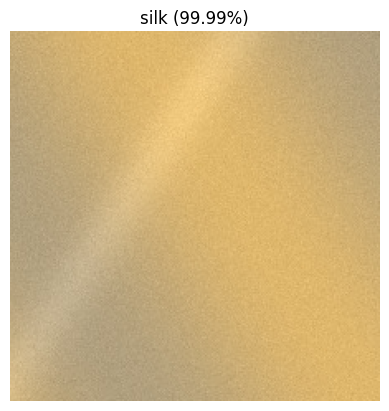

silk_008.jpg -> Predicted Fabric: silk (99.99%)


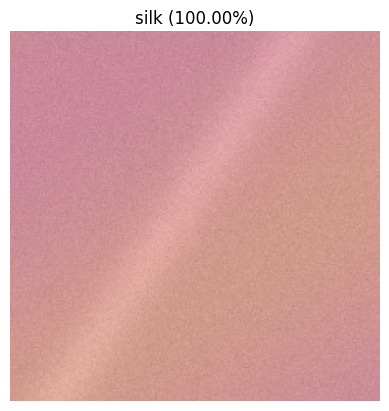

silk_007.jpg -> Predicted Fabric: silk (100.00%)


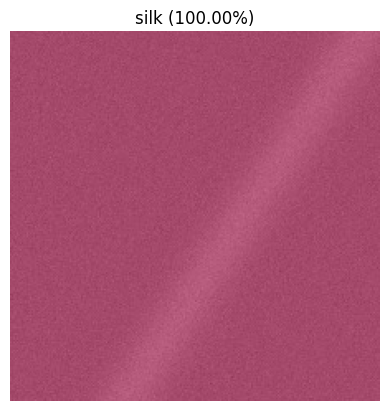

silk_015.jpg -> Predicted Fabric: silk (100.00%)


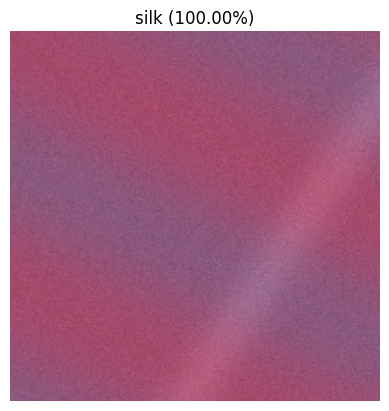

silk_013.jpg -> Predicted Fabric: silk (100.00%)


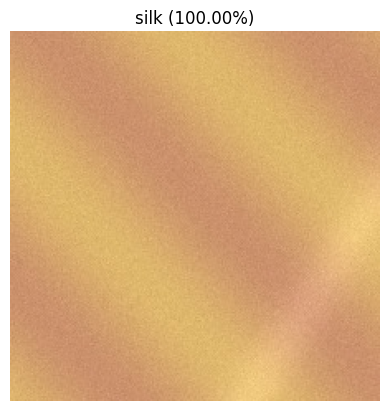

silk_005.jpg -> Predicted Fabric: silk (100.00%)


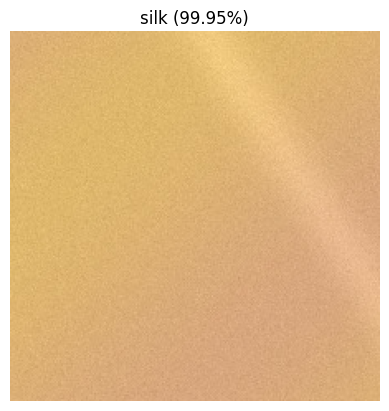

silk_009.jpg -> Predicted Fabric: silk (99.95%)


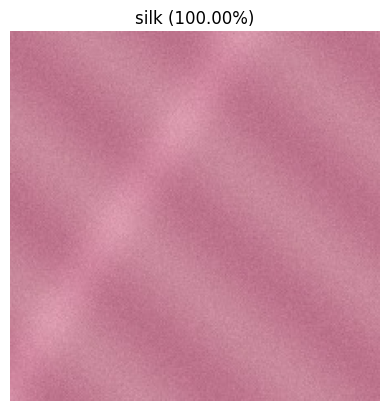

silk_001.jpg -> Predicted Fabric: silk (100.00%)


In [ ]:
import zipfile
import tempfile

new_upload = files.upload()

for fname in new_upload:
    # If the user uploads a zip file instead of an image
    if fname.lower().endswith('.zip'):
        print(f"Extracting and predicting on images inside ZIP file: {fname}")
        with tempfile.TemporaryDirectory() as tmpdir:
            with zipfile.ZipFile(fname, 'r') as zip_ref:
                zip_ref.extractall(tmpdir)

            # Find all images in extracted folder
            extracted_fnames = []
            for root, dirs, files_list in os.walk(tmpdir):
                for file in files_list:
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        extracted_fnames.append(os.path.join(root, file))

            # Predict on extracted images
            for ext_path in extracted_fnames[:10]: # Limit to first 10 to avoid notebook clutter
                img = Image.open(ext_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
                img_array = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
                img_array = preprocess_input(img_array)

                predictions = fabric_model.predict(img_array, verbose=0)
                predicted_index = np.argmax(predictions[0])
                predicted_fabric = fabric_labels[predicted_index]
                confidence = predictions[0][predicted_index] * 100

                plt.imshow(img); plt.axis('off')
                plt.title(f"{predicted_fabric} ({confidence:.2f}%)"); plt.show()
                print(f"{os.path.basename(ext_path)} -> Predicted Fabric: {predicted_fabric} ({confidence:.2f}%)")
    else:
        # Standard direct image upload
        img = Image.open(fname).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
        img_array = preprocess_input(img_array)

        predictions = fabric_model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions[0])
        predicted_fabric = fabric_labels[predicted_index]
        confidence = predictions[0][predicted_index] * 100

        plt.imshow(img); plt.axis('off')
        plt.title(f"{predicted_fabric} ({confidence:.2f}%)"); plt.show()
        print(f"{fname} -> Predicted Fabric: {predicted_fabric} ({confidence:.2f}%)")

In [ ]:
print(len([f for f in os.listdir('/content') if f.endswith('.jpg')]), "images found")

80 images found


In [ ]:
import zipfile, shutil

uploaded = files.upload()   # select your .zip file

for name in uploaded:
    if name.endswith('.zip'):
        with zipfile.ZipFile(name) as z:
            z.extractall('/content/unzipped')

# move all images from the unzipped folders into /content so Step 1 finds them
for root, _, fnames in os.walk('/content/unzipped'):
    for fn in fnames:
        if fn.lower().endswith(('.jpg', '.jpeg', '.png')) and not fn.startswith('.'):
            shutil.copy(os.path.join(root, fn), os.path.join('/content', fn))

print(len([f for f in os.listdir('/content') if f.endswith('.jpg')]), "images ready")

Saving fabric_dataset_starter (1).zip to fabric_dataset_starter (1) (2).zip
80 images ready


#Save the model and the labels

In [ ]:
import json
fabric_model.save("fabric_model.keras")
with open("fabric_labels.json", "w") as f:
    json.dump(fabric_labels, f)

files.download("fabric_model.keras")
files.download("fabric_labels.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
new_upload = ["denim_004.jpg"]   # any file already in /content